In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração para exibir todas as colunas
pd.set_option('display.max_columns', None)

# Carregando os datasets principais da Olist
customers_df = pd.read_csv('../data/olist_customers_dataset.csv')
orders_df = pd.read_csv('../data/olist_orders_dataset.csv')
items_df = pd.read_csv('../data/olist_order_items_dataset.csv')

# Exibindo as primeiras linhas do dataset de clientes
print("Tamanho do dataset de Clientes:", customers_df.shape)
customers_df.head()

Tamanho do dataset de Clientes: (99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [6]:
# Converter colunas de data para o formato datetime no dataset de pedidos
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])

# Verificar o intervalo de tempo das compras na plataforma
data_minima = orders_df['order_purchase_timestamp'].min()
data_maxima = orders_df['order_purchase_timestamp'].max()

print(f"Primeira compra registada: {data_minima}")
print(f"Última compra registada:    {data_maxima}")
print(f"Total de dias de histórico: {(data_maxima - data_minima).days} dias\n")

# Analisar a distribuição dos estados dos pedidos
print("Distribuição dos estados dos pedidos:")
print(orders_df['order_status'].value_counts())

Primeira compra registada: 2016-09-04 21:15:19
Última compra registada:    2018-10-17 17:30:18
Total de dias de histórico: 772 dias

Distribuição dos estados dos pedidos:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [11]:
# Unir o dataset de pedidos com o de clientes para obter o customer_unique_id
orders_with_customers = orders_df.merge(customers_df, on='customer_id', how='inner')

# Filtrar apenas pedidos entregues
delivered_orders = orders_with_customers[orders_with_customers['order_status'] == 'delivered']

# Contar número de pedidos por cliente único
orders_per_customer = delivered_orders.groupby('customer_unique_id')['order_id'].nunique()

# Estatísticas de frequência
print("Distribuição do número de pedidos por cliente único:")
print(orders_per_customer.value_counts())

print(f"\nPercentagem de clientes que compraram APENAS 1 vez: {(orders_per_customer == 1).mean() * 100:.2f}%")

Distribuição do número de pedidos por cliente único:
order_id
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

Percentagem de clientes que compraram APENAS 1 vez: 97.00%


In [12]:
# Definir a data de referência (snapshot) como o dia seguinte à última compra no dataset
snapshot_date = orders_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Agrupar por cliente único para calcular a recência (dias desde a última compra)
customer_recency = delivered_orders.groupby('customer_unique_id').agg(
    last_purchase_date=('order_purchase_timestamp', 'max')
).reset_index()

customer_recency['recency_days'] = (snapshot_date - customer_recency['last_purchase_date']).dt.days

# Visualizar estatísticas da recência
print(f"Data da análise (Snapshot): {snapshot_date.strftime('%Y-%m-%d')}\n")
print("Estatísticas descritivas da Recência (em dias):")
print(customer_recency['recency_days'].describe())

Data da análise (Snapshot): 2018-10-18

Estatísticas descritivas da Recência (em dias):
count    93358.000000
mean       287.105465
std        152.591705
min         50.000000
25%        164.000000
50%        268.000000
75%        395.000000
max        763.000000
Name: recency_days, dtype: float64


Distribuição do Churn (Limite = 90 dias):
Ativos (0):   9201 (9.86%)
Churned (1):  84157 (90.14%)



C:\Users\lucas\AppData\Local\Temp\ipykernel_3084\2039811799.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_churn', data=customer_recency, palette=['#2ecc71', '#e74c3c'])


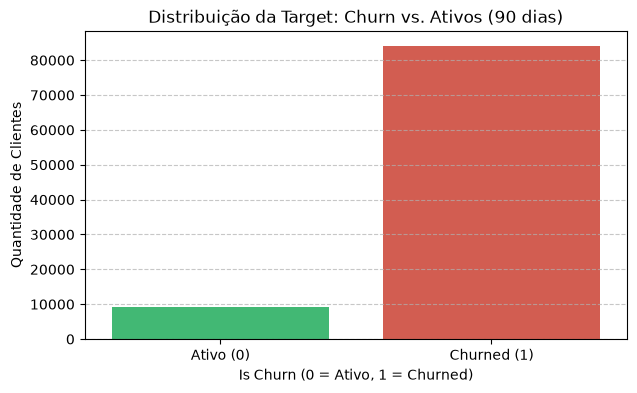

In [13]:
# Definir o limite temporal de churn (90 dias)
CHURN_THRESHOLD_DAYS = 90

# Criar a coluna target binária: 1 para Churn, 0 para Ativo
customer_recency['is_churn'] = (customer_recency['recency_days'] > CHURN_THRESHOLD_DAYS).astype(int)

# Contagem e percentagem da variável Target
churn_counts = customer_recency['is_churn'].value_counts()
churn_percentages = customer_recency['is_churn'].value_counts(normalize=True) * 100

print(f"Distribuição do Churn (Limite = {CHURN_THRESHOLD_DAYS} dias):")
print(f"Ativos (0):   {churn_counts.get(0, 0)} ({churn_percentages.get(0, 0):.2f}%)")
print(f"Churned (1):  {churn_counts.get(1, 0)} ({churn_percentages.get(1, 0):.2f}%)\n")

# Gráfico de barras da distribuição do Churn
plt.figure(figsize=(7, 4))
sns.countplot(x='is_churn', data=customer_recency, palette=['#2ecc71', '#e74c3c'])
plt.title(f'Distribuição da Target: Churn vs. Ativos ({CHURN_THRESHOLD_DAYS} dias)')
plt.xlabel('Is Churn (0 = Ativo, 1 = Churned)')
plt.ylabel('Quantidade de Clientes')
plt.xticks([0, 1], ['Ativo (0)', 'Churned (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [14]:
# 1. Carregar e unificar pedidos, itens e avaliações
items_orders = items_df.merge(delivered_orders, on='order_id', how='inner')

# Carregar dataset de avaliações (reviews)
reviews_df = pd.read_csv('../data/olist_order_reviews_dataset.csv')
full_df = items_orders.merge(reviews_df, on='order_id', how='left')

# 2. Calcular o valor total gasto por item (preço + frete)
full_df['total_item_price'] = full_df['price'] + full_df['freight_value']

# 3. Agregação por cliente único (Feature Engineering)
features_df = full_df.groupby('customer_unique_id').agg(
    total_spent=('total_item_price', 'sum'),
    avg_item_price=('price', 'mean'),
    avg_freight_value=('freight_value', 'mean'),
    total_items=('order_item_id', 'count'),
    avg_review_score=('review_score', 'mean')
).reset_index()

# 4. Unir as features criadas com a nossa variável Target (is_churn)
dataset_final = customer_recency[['customer_unique_id', 'recency_days', 'is_churn']].merge(
    features_df, on='customer_unique_id', how='inner'
)

print(f"Dataset de Treino Criado! Total de Clientes: {dataset_final.shape[0]} | Total de Colunas: {dataset_final.shape[1]}")
dataset_final.head()

Dataset de Treino Criado! Total de Clientes: 93358 | Total de Colunas: 8


,customer_unique_id,recency_days,is_churn,total_spent,avg_item_price,avg_freight_value,total_items,avg_review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,129.90,12.00,1,5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,18.90,8.29,1,4.0
2,0000f46a3911fa3c0805444483337064,586,1,86.22,69.00,17.22,1,3.0
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,25.99,17.63,1,4.0
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,180.00,16.89,1,5.0
